In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset
all_time = pd.read_csv("/kaggle/input/datasets/alitaqishah/spotify-wrapped-2025-top-songs-and-artists/spotify_alltime_top100_songs.csv")
artist_top = pd.read_csv("/kaggle/input/datasets/alitaqishah/spotify-wrapped-2025-top-songs-and-artists/spotify_wrapped_2025_top50_artists.csv")
song_top = pd.read_csv("/kaggle/input/datasets/alitaqishah/spotify-wrapped-2025-top-songs-and-artists/spotify_wrapped_2025_top50_songs.csv")
print('Loaded!')

Loaded!


In [7]:
print(all_time.shape)
print(all_time.columns.tolist())
print('\n')
print(artist_top.shape)
print(artist_top.columns.tolist())
print('\n')
print(song_top.shape)
print(song_top.columns.tolist())

(100, 14)
['alltime_rank', 'song_title', 'artist', 'total_streams_billions', 'primary_genre', 'bpm', 'release_year', 'artist_country', 'explicit', 'danceability', 'energy', 'valence', 'acousticness', 'dataset_part']


(50, 11)
['wrapped_2025_rank', 'artist_name', 'monthly_listeners_millions_mar2026', 'primary_genre', 'country', 'followers_millions', 'grammy_wins', 'debut_year', 'gender', 'top_2025_song', 'dataset_part']


(50, 16)
['wrapped_2025_rank', 'song_title', 'artist', 'streams_2025_billions', 'primary_genre', 'bpm', 'duration_seconds', 'release_year', 'artist_country', 'explicit', 'danceability', 'energy', 'valence', 'acousticness', 'peak_global_chart_position', 'dataset_part']


In [9]:
print(all_time.head())
print('\nartist:')
print(artist_top.head())
print('\nsong:')
print(song_top.head())

   alltime_rank         song_title                  artist  \
0             1    Blinding Lights              The Weeknd   
1             2       Shape of You              Ed Sheeran   
2             3  Someone You Loved           Lewis Capaldi   
3             4          Sunflower  Post Malone & Swae Lee   
4             5          One Dance                   Drake   

   total_streams_billions  primary_genre  bpm  release_year artist_country  \
0                    5.26      Synth-Pop  171          2019         Canada   
1                    4.90  Pop/Dancehall   96          2017             UK   
2                    4.05            Pop   77          2018             UK   
3                    3.98    Hip-Hop/Pop   93          2018            USA   
4                    3.92  Afrobeats/Pop  100          2016         Canada   

   explicit  danceability  energy  valence  acousticness  \
0     False          0.51    0.80     0.33          0.00   
1     False          0.83    0.65     

In [10]:
print(all_time.isnull().sum())
print(artist_top.isnull().sum())
print(song_top.isnull().sum())

alltime_rank              0
song_title                0
artist                    0
total_streams_billions    0
primary_genre             0
bpm                       0
release_year              0
artist_country            0
explicit                  0
danceability              0
energy                    0
valence                   0
acousticness              0
dataset_part              0
dtype: int64
wrapped_2025_rank                     0
artist_name                           0
monthly_listeners_millions_mar2026    0
primary_genre                         0
country                               0
followers_millions                    0
grammy_wins                           0
debut_year                            0
gender                                0
top_2025_song                         0
dataset_part                          0
dtype: int64
wrapped_2025_rank             0
song_title                    0
artist                        0
streams_2025_billions         0
primary_genre 

In [13]:
print(all_time.dtypes)
print('\n')
print(artist_top.dtypes)
print('\n')
print(song_top.dtypes)


alltime_rank                int64
song_title                 object
artist                     object
total_streams_billions    float64
primary_genre              object
bpm                         int64
release_year                int64
artist_country             object
explicit                     bool
danceability              float64
energy                    float64
valence                   float64
acousticness              float64
dataset_part               object
dtype: object


wrapped_2025_rank                       int64
artist_name                            object
monthly_listeners_millions_mar2026    float64
primary_genre                          object
country                                object
followers_millions                      int64
grammy_wins                             int64
debut_year                              int64
gender                                 object
top_2025_song                          object
dataset_part                           object
dt

In [16]:
artist_top.rename(columns={'artist_name':'artist'})

,wrapped_2025_rank,artist,monthly_listeners_millions_mar2026,primary_genre,country,followers_millions,grammy_wins,debut_year,gender,top_2025_song,dataset_part
0,1,The Weeknd,110.4,R&B/Pop,Canada,112,4,2010,Male,Die With A Smile,Spotify Wrapped 2025 Top 50 Artists
1,2,Taylor Swift,107.5,Pop/Country,USA,110,14,2006,Female,Fortnight,Spotify Wrapped 2025 Top 50 Artists
2,3,Drake,88.6,Hip-Hop,Canada,95,4,2006,Male,Amen,Spotify Wrapped 2025 Top 50 Artists
3,4,Bad Bunny,84.2,Reggaeton,Puerto Rico,89,0,2016,Male,NUEVAYoL,Spotify Wrapped 2025 Top 50 Artists
4,5,Sabrina Carpenter,82.1,Pop,USA,58,0,2015,Female,Espresso,Spotify Wrapped 2025 Top 50 Artists
5,6,Billie Eilish,78.5,Indie Pop,USA,110,9,2015,Female,Birds Of A Feather,Spotify Wrapped 2025 Top 50 Artists
6,7,Ed Sheeran,76.3,Pop/Folk,UK,115,4,2011,Male,Azizam,Spotify Wrapped 2025 Top 50 Artists
7,8,Ariana Grande,72.8,Pop/R&B,USA,94,2,2013,Female,we can't be friends,Spotify Wrapped 2025 Top 50 Artists
8,9,Kendrick Lamar,71.5,Hip-Hop,USA,52,17,2003,Male,Not Like Us,Spotify Wrapped 2025 Top 50 Artists
9,10,Harry Styles,70.2,Pop,UK,80,0,2010,Male,Music For a Sushi Restaurant,Spotify Wrapped 2025 Top 50 Artists


In [18]:
all_time.drop('dataset_part', axis=1)
artist_top.drop('dataset_part', axis=1)
song_top.drop('dataset_part',axis=1)

,wrapped_2025_rank,song_title,artist,streams_2025_billions,primary_genre,bpm,duration_seconds,release_year,artist_country,explicit,danceability,energy,valence,acousticness,peak_global_chart_position
0,1,Die With A Smile,Lady Gaga & Bruno Mars,1.70,Pop,120,251,2024,USA,False,0.72,0.68,0.55,0.18,1
1,2,APT.,ROSE & Bruno Mars,1.62,K-Pop/Pop,145,173,2024,South Korea,False,0.86,0.79,0.88,0.05,1
2,3,Espresso,Sabrina Carpenter,1.55,Pop,104,175,2024,USA,False,0.80,0.73,0.96,0.06,1
3,4,Please Please Please,Sabrina Carpenter,1.48,Pop,107,186,2024,USA,False,0.70,0.66,0.87,0.10,1
4,5,Taste,Sabrina Carpenter,1.41,Pop,117,177,2024,USA,True,0.78,0.70,0.82,0.08,1
5,6,Birds Of A Feather,Billie Eilish,1.38,Indie Pop,88,210,2024,USA,False,0.75,0.44,0.65,0.38,1
6,7,Not Like Us,Kendrick Lamar,1.35,Hip-Hop,101,274,2024,USA,True,0.82,0.72,0.62,0.04,1
7,8,"Good Luck, Babe!",Chappell Roan,1.29,Pop,131,219,2024,USA,False,0.66,0.78,0.56,0.04,1
8,9,Beautiful Things,Benson Boone,1.24,Pop Rock,97,211,2024,USA,False,0.46,0.68,0.46,0.07,1
9,10,Lose Control,Teddy Swims,1.20,R&B/Soul,90,202,2023,USA,False,0.60,0.55,0.64,0.21,1


In [19]:
# creating label for each
all_time['era'] = 'All-Time'
song_top['era'] = '2025'

In [21]:
common_cols = ['artist', 'bpm', 'song_title', 'primary_genre', 'artist_country', 'explicit', 'release_year', 'era']
# concat
df = pd.concat([all_time[common_cols], song_top[common_cols]], axis=0)

In [24]:
print(df['era'].value_counts())

era
All-Time    100
2025         50
Name: count, dtype: int64


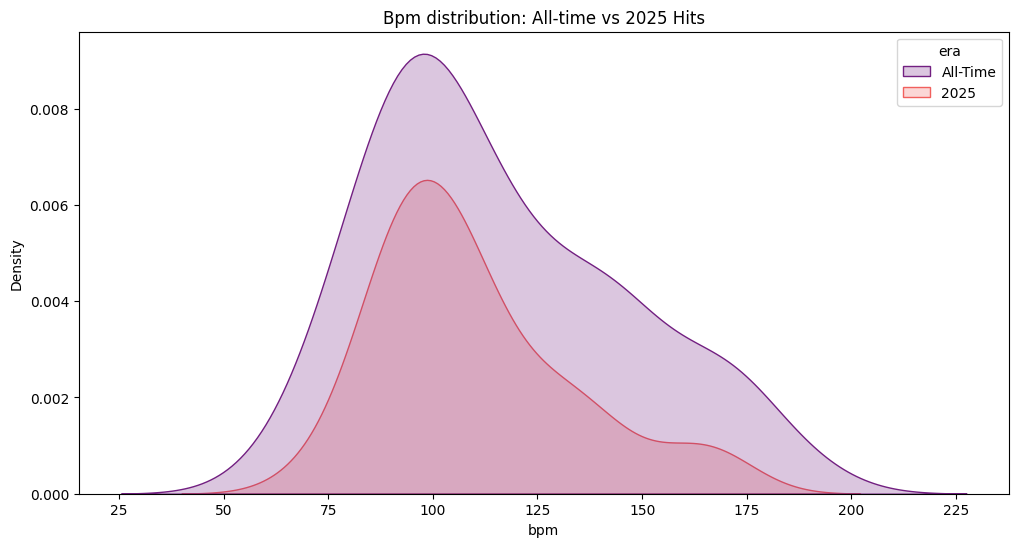

In [25]:
plt.figure(figsize=(12,6))
sns.kdeplot(data=df, x='bpm', hue='era', fill=True, palette='magma')
plt.title('Bpm distribution: All-time vs 2025 Hits')
plt.show()

In [32]:
print(df.columns.tolist())

['artist', 'bpm', 'song_title', 'primary_genre', 'artist_country', 'explicit', 'release_year', 'era']


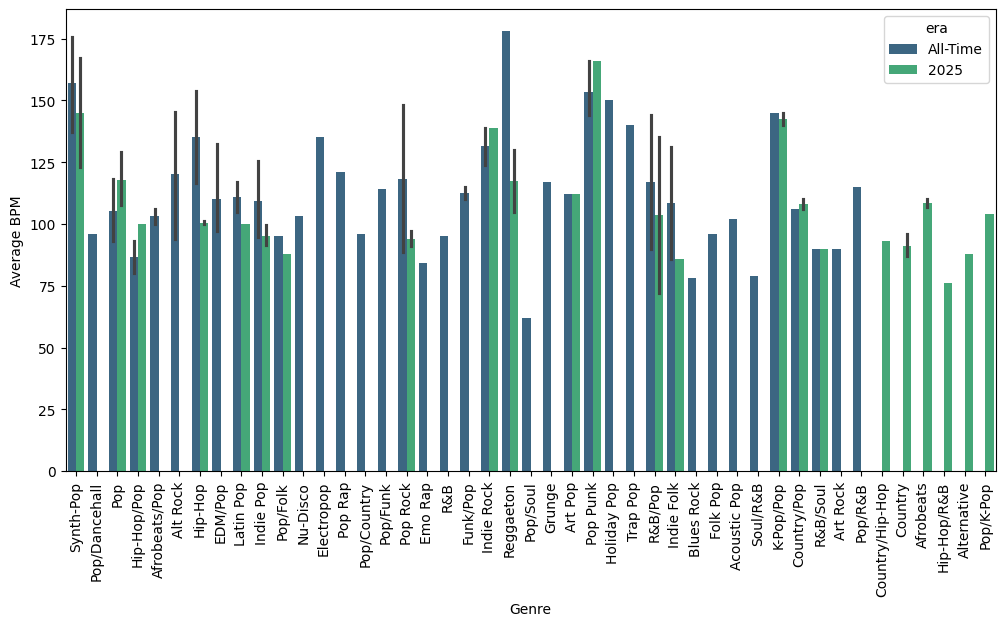

In [38]:
top_genres = df['primary_genre'].value_counts().head(3).index
df_top_genres = df[df['primary_genre'].isin(top_genres)]

plt.figure(figsize=(12,6))
sns.barplot(data=df, x='primary_genre', y='bpm', hue='era', palette='viridis')
plt.ylabel('Average BPM')
plt.xlabel('Genre')
plt.xticks(rotation=90)
plt.show()